<a href="https://colab.research.google.com/github/sjdyeet/concept_of_ai/blob/main/regression_2501589.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install & Import Libraries
!pip install -q scikit-learn==1.3.2 matplotlib pandas seaborn tensorflow==2.15.0 joblib

# Imports
import os
import math
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,6)

# sklearn & tensorflow
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Imports complete. ", tf.__version__)


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Imports complete.  2.19.0


In [ ]:
# Load Dataset & Save Provenance
csv_path = "/content/sample_data/social_media_vs_productivity.csv"



df = pd.read_csv(csv_path)
print("Loaded file:", csv_path)
print("Shape:", df.shape)
display(df.head())

# Save a small provenance JSON for the report
prov = {
    "dataset_name": "social_media_vs_productivity",
    "author_on_kaggle": "mahdimashayekhi (Kaggle)",
    "local_path": csv_path,
    "loaded_at_utc": datetime.utcnow().isoformat()
}
with open("dataset_provenance.json", "w") as f:
    json.dump(prov, f, indent=2)
print("Saved dataset_provenance.json")


Loaded file: /content/sample_data/social_media_vs_productivity.csv
Shape: (30000, 19)


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,25,Male,IT,NaN,Telegram,66,6.214096,8.868753,NaN,7.0,5.405706,1.876254,1,False,True,1,30,10.653519,9.693060


Saved dataset_provenance.json


In [ ]:
#View Columns, Data Types, Summary & Missing Values
print("Columns:\n", df.columns.tolist())
print("\nData types and non-null counts:")
display(df.info())

print("\nBasic statistics for numeric columns:")
display(df.describe().T)

# Show missing values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing>0].head(50))


Columns:
 ['age', 'gender', 'job_type', 'daily_social_media_time', 'social_platform_preference', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'actual_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             30000 non-null  int64  
 1   gender                          30000 non-null  object 
 2   job_type                        30000 non-null  object 
 3   daily_social_media_time         27235 non-null  float64
 4   social_platform_preference      3

None


Basic statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
age,30000.0,41.486867,13.835221,18.000000,30.000000,41.000000,53.000000,65.000000
daily_social_media_time,27235.0,3.113418,2.074813,0.000000,1.639566,3.025913,4.368917,17.973256
number_of_notifications,30000.0,59.958767,7.723772,30.000000,55.000000,60.000000,65.000000,90.000000
work_hours_per_day,30000.0,6.990792,1.997736,0.000000,5.643771,6.990641,8.354725,12.000000
perceived_productivity_score,28386.0,5.510488,2.023470,2.000252,3.757861,5.525005,7.265776,8.999376
actual_productivity_score,27635.0,4.951805,1.883378,0.296812,3.373284,4.951742,6.526342,9.846258
stress_level,28096.0,5.514059,2.866344,1.000000,3.000000,6.000000,8.000000,10.000000
sleep_hours,27402.0,6.500247,1.464004,3.000000,5.493536,6.498340,7.504143,10.000000
screen_time_before_sleep,27789.0,1.025568,0.653355,0.000000,0.528490,1.006159,1.477221,3.000000
breaks_during_work,30000.0,4.992200,3.173737,0.000000,2.000000,5.000000,8.000000,10.000000


,0
daily_social_media_time,2765
job_satisfaction_score,2730
sleep_hours,2598
actual_productivity_score,2365
screen_time_before_sleep,2211
stress_level,1904
perceived_productivity_score,1614


Candidate target columns: ['perceived_productivity_score', 'actual_productivity_score', 'job_satisfaction_score']
Using target column: actual_productivity_score
Rows total: 30000; rows with target NaN: 2365


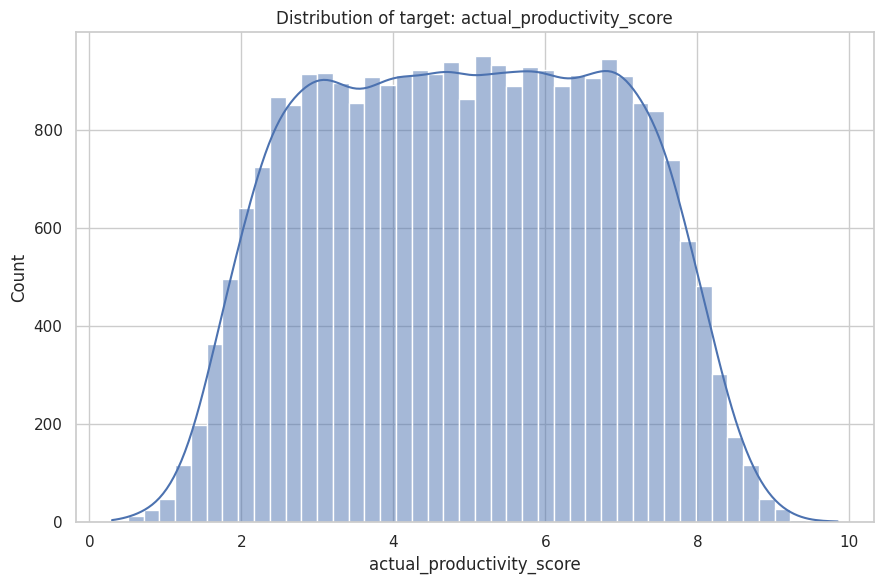

In [ ]:
#Detect Target Column Automatically
candidates = [c for c in df.columns if ('productivity' in c.lower()) or ('actual' in c.lower()) or ('score' in c.lower())]
print("Candidate target columns:", candidates)

preferred_order = ['actual_productivity_score', 'actual_productivity',
                   'perceived_productivity_score', 'productivity_score', 'productivity']
target_col = None
for p in preferred_order:
    if p in df.columns:
        target_col = p
        break
if target_col is None and len(candidates)>0:
    target_col = candidates[0]

# If automatic detection fails, set target_col manually here
if target_col is None:
    raise SystemExit("Could not detect a productivity target column automatically. Inspect df.columns and set target_col manually.")

print("Using target column:", target_col)

# Count missing targets
n_total = df.shape[0]
n_target_nan = df[target_col].isna().sum()
print(f"Rows total: {n_total}; rows with target NaN: {n_target_nan}")

# Distribution of target
plt.figure()
sns.histplot(df[target_col].dropna(), kde=True)
plt.title(f"Distribution of target: {target_col}")
plt.xlabel(target_col)
plt.tight_layout()
plt.show()


In [ ]:

# Drop rows with missing target (cannot train on missing labels)
if df[target_col].isna().sum() > 0:
    print("Dropping rows with missing target:", df[target_col].isna().sum())
    df = df.dropna(subset=[target_col]).reset_index(drop=True)
else:
    print("No missing targets.")

# Optional: drop obvious ID columns if present
id_like = [c for c in df.columns if c.lower() in ('id','index','userid','user_id','person_id','name')]
if id_like:
    print("Dropping ID-like columns:", id_like)
    df = df.drop(columns=id_like)

# Separate X and y
y = df[target_col]
X = df.drop(columns=[target_col]).copy()

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Build preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessor on X (used for transformation later)
preprocessor.fit(X)

# Build transformed feature names list (for feature selection mapping)
num_names = numeric_features
cat_names = []
if categorical_features:
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_names = list(ohe.get_feature_names_out(categorical_features))
    except Exception:
        # fallback if no categories or OHE unavailable
        cat_names = []
transformed_feature_names = num_names + cat_names
print("Transformed feature count:", len(transformed_feature_names))


Dropping rows with missing target: 2365
Numeric features: ['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']
Categorical features: ['gender', 'job_type', 'social_platform_preference']
Transformed feature count: 27


In [ ]:
#rain-Test Split & Pipeline Creation
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train/test shapes:", X_train.shape, X_test.shape)
print("Ensure no NaNs in y:", y_train.isna().sum(), y_test.isna().sum())

# Evaluation helper
def eval_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Baseline Ridge
pipe_ridge = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=42))])
pipe_ridge.fit(X_train, y_train)
pred_ridge = pipe_ridge.predict(X_test)
ridge_baseline = eval_regression(y_test, pred_ridge)
print("Ridge baseline results:", ridge_baseline)

# Baseline RandomForest
pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)
rf_baseline = eval_regression(y_test, pred_rf)
print("RandomForest baseline results:", rf_baseline)


Train/test shapes: (22108, 18) (5527, 18)
Ensure no NaNs in y: 0 0
Ridge baseline results: {'MSE': 0.339486680712481, 'RMSE': 0.5826548555641504, 'MAE': 0.4284205871398165, 'R2': 0.9057646661147021}
RandomForest baseline results: {'MSE': 0.27322154426105194, 'RMSE': 0.5227059826145593, 'MAE': 0.40308562559154965, 'R2': 0.9241586639155874}


In [ ]:
#Hyperparameter Tuning for Ridge Regression
print("Tuning Ridge (alpha) with GridSearchCV...")
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0]}
gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train, y_train)
print("Ridge best params:", gs_ridge.best_params_, "best CV (neg MSE):", gs_ridge.best_score_)

print("\nTuning RandomForest with GridSearchCV")
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=4, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("RandomForest best params:", gs_rf.best_params_, "best CV (neg MSE):", gs_rf.best_score_)


Tuning Ridge (alpha) with GridSearchCV...
Ridge best params: {'model__alpha': 10.0} best CV (neg MSE): -0.32562420226919453

Tuning RandomForest with GridSearchCV
RandomForest best params: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200} best CV (neg MSE): -0.25666404826021927


In [ ]:

# Transform train/test to numeric matrices
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()

# choose k features (cap at 12)
k = min(12, X_train_trans.shape[1])
print("Selecting top k =", k)

# SelectKBest (filter)
skb = SelectKBest(score_func=f_regression, k=k)
skb.fit(X_train_trans, y_train)
top_idx = np.argsort(skb.scores_)[-k:][::-1]
top_features = [transformed_feature_names[i] for i in top_idx]
print("Top features by SelectKBest:", top_features)

# RFE wrapper with RandomForest to cross-check
rfe_est = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rfe = RFE(rfe_est, n_features_to_select=k, step=0.1)
rfe.fit(X_train_trans, y_train)
rfe_selected = [name for name, sel in zip(transformed_feature_names, rfe.support_) if sel]
print("Top features by RFE:", rfe_selected)

# Intersection of both methods
selected_features = [f for f in top_features if f in rfe_selected]
if not selected_features:
    selected_features = top_features  # fallback if no intersection
print("Final selected features:", selected_features)

# Build selected matrices
selected_indices = [transformed_feature_names.index(f) for f in selected_features]
X_train_sel = X_train_trans[:, selected_indices]
X_test_sel = X_test_trans[:, selected_indices]
print("Selected feature matrices shapes:", X_train_sel.shape, X_test_sel.shape)


Selecting top k = 12
Top features by SelectKBest: ['perceived_productivity_score', 'job_satisfaction_score', 'days_feeling_burnout_per_month', 'job_type_IT', 'job_type_Student', 'coffee_consumption_per_day', 'gender_Other', 'daily_social_media_time', 'sleep_hours', 'social_platform_preference_Twitter', 'job_type_Education', 'job_type_Health']
Top features by RFE: ['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'perceived_productivity_score', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score']
Final selected features: ['perceived_productivity_score', 'job_satisfaction_score', 'days_feeling_burnout_per_month', 'daily_social_media_time', 'sleep_hours']
Selected feature matrices shapes: (22108, 5) (5527, 5)


In [ ]:
#Train Final Ridge Regression Model

# Ridge final
best_alpha = gs_ridge.best_params_['model__alpha']
final_ridge = Ridge(alpha=best_alpha, random_state=42)
final_ridge.fit(X_train_sel, y_train)
pred_ridge_final = final_ridge.predict(X_test_sel)
ridge_final_metrics = eval_regression(y_test, pred_ridge_final)
print("Final Ridge metrics:", ridge_final_metrics)

# RandomForest final
best_rf_params = gs_rf.best_params_
rf_kwargs = {
    'n_estimators': best_rf_params.get('model__n_estimators', 200),
    'max_depth': best_rf_params.get('model__max_depth', None),
    'min_samples_split': best_rf_params.get('model__min_samples_split', 2),
    'random_state': 42,
    'n_jobs': -1
}
final_rf = RandomForestRegressor(**rf_kwargs)
final_rf.fit(X_train_sel, y_train)
pred_rf_final = final_rf.predict(X_test_sel)
rf_final_metrics = eval_regression(y_test, pred_rf_final)
print("Final RandomForest metrics:", rf_final_metrics)

# Summary table
import pandas as pd
final_table = pd.DataFrame([
    ['Ridge (baseline)', ridge_baseline['RMSE'], ridge_baseline['R2']],
    ['RF (baseline)', rf_baseline['RMSE'], rf_baseline['R2']],
    ['Ridge (final)', ridge_final_metrics['RMSE'], ridge_final_metrics['R2']],
    ['RF (final)', rf_final_metrics['RMSE'], rf_final_metrics['R2']]
], columns=['Model','Test RMSE','Test R2'])
display(final_table)


Final Ridge metrics: {'MSE': 0.33885278587592194, 'RMSE': 0.5821106302722207, 'MAE': 0.4283120998572789, 'R2': 0.9059406238030743}
Final RandomForest metrics: {'MSE': 0.2642498802221432, 'RMSE': 0.5140524099954626, 'MAE': 0.39663133154602925, 'R2': 0.9266490348321693}


,Model,Test RMSE,Test R2
0,Ridge (baseline),0.582655,0.905765
1,RF (baseline),0.522706,0.924159
2,Ridge (final),0.582111,0.905941
3,RF (final),0.514052,0.926649


Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 25.
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLP metrics: {'MSE': 0.2973183101816784, 'RMSE': 0.5452690255109659, 'MAE': 0.4193084248305319, 'R2': 0.9174698395489865}


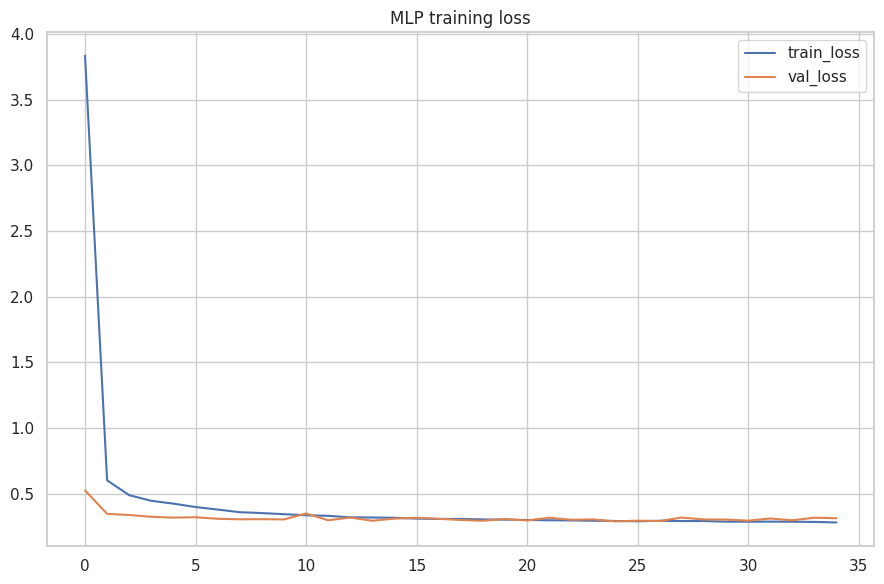

In [ ]:
#Neural Network Regression Model
scaler_sel = StandardScaler()
X_train_nn = scaler_sel.fit_transform(X_train_sel)
X_test_nn = scaler_sel.transform(X_test_sel)

def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])
    return model

mlp = build_mlp(X_train_nn.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = mlp.fit(X_train_nn, y_train, validation_split=0.15, epochs=200, batch_size=32, callbacks=[es], verbose=0)

mlp_preds = mlp.predict(X_test_nn).ravel()
mlp_metrics = eval_regression(y_test, mlp_preds)
print("MLP metrics:", mlp_metrics)

# Plot training/validation loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("MLP training loss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:


# Feature importance from RandomForest (final)
feat_importances = pd.Series(final_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("RandomForest feature importances:")
display(feat_importances)

# Permutation importance
perm = permutation_importance(final_rf, X_test_sel, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=selected_features).sort_values(ascending=False)
print("Permutation importances (mean):")
display(perm_imp)

# Save models and scaler
joblib.dump(final_ridge, "final_ridge.joblib")
joblib.dump(final_rf, "final_rf.joblib")
joblib.dump(scaler_sel, "scaler_selected.joblib")
mlp.save("final_mlp_model.keras")

# Save summary for report
summary = {
    'dataset_path': csv_path,
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'target': target_col,
    'selected_features': selected_features,
    'ridge_final_metrics': ridge_final_metrics,
    'rf_final_metrics': rf_final_metrics,
    'mlp_metrics': mlp_metrics,
    'ridge_best_params': gs_ridge.best_params_,
    'rf_best_params': gs_rf.best_params_,
    'saved_at_utc': datetime.utcnow().isoformat()
}
with open("project_summary_regression.json", "w") as f:
    json.dump(summary, f, indent=2)

# Save comparison CSV
final_table = pd.DataFrame([
    ['Ridge (baseline)', ridge_baseline['RMSE'], ridge_baseline['R2']],
    ['RF (baseline)', rf_baseline['RMSE'], rf_baseline['R2']],
    ['Ridge (final)', ridge_final_metrics['RMSE'], ridge_final_metrics['R2']],
    ['RF (final)', rf_final_metrics['RMSE'], rf_final_metrics['R2']],
    ['MLP (final)', mlp_metrics['RMSE'], mlp_metrics['R2']]
], columns=['Model','Test RMSE','Test R2'])
final_table.to_csv("model_comparison_regression.csv", index=False)

print("Saved models and summary files:")
print(" - final_ridge.joblib, final_rf.joblib, final_mlp_model.keras")
print(" - project_summary_regression.json, model_comparison_regression.csv")
display(final_table)


RandomForest feature importances:


,0
perceived_productivity_score,0.938305
job_satisfaction_score,0.052521
sleep_hours,0.003568
daily_social_media_time,0.003112
days_feeling_burnout_per_month,0.002493


Permutation importances (mean):


,0
perceived_productivity_score,1.379456
job_satisfaction_score,0.121577
sleep_hours,0.000180
daily_social_media_time,0.000166
days_feeling_burnout_per_month,-0.000188


Saved models and summary files:
 - final_ridge.joblib, final_rf.joblib, final_mlp_model.keras
 - project_summary_regression.json, model_comparison_regression.csv


,Model,Test RMSE,Test R2
0,Ridge (baseline),0.582655,0.905765
1,RF (baseline),0.522706,0.924159
2,Ridge (final),0.582111,0.905941
3,RF (final),0.514052,0.926649
4,MLP (final),0.545269,0.917470
